In [1]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from typing import Annotated, List
import operator
from langgraph.constants import Send
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, SystemMessage

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm=ChatGroq(model="qwen-2.5-32b")

result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 30, 'total_tokens': 40, 'completion_time': 0.05, 'prompt_time': 0.003670581, 'queue_time': 0.228741105, 'total_time': 0.053670581}, 'model_name': 'qwen-2.5-32b', 'system_fingerprint': 'fp_35f92f8282', 'finish_reason': 'stop', 'logprobs': None}, id='run-98676f20-10c8-402b-800f-c5e4afe76862-0', usage_metadata={'input_tokens': 30, 'output_tokens': 10, 'total_tokens': 40})

In [3]:

class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the blog",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )
class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )

# Augment the LLM with schema for structured output
planner = llm.with_structured_output(Sections)

In [4]:
# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report

# Worker state
class WorkerState(TypedDict):
    section: Section

In [32]:
# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    result = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the blog post which includes indroduction,  sections followed by overall conclusion."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )
    return {"sections": result.sections}

def llm_generate_sub_sections(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a blog section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}

def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}

# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_generate_sub_sections", {"section": s}) for s in state["sections"]]

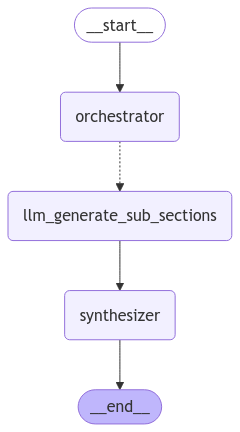

In [ ]:
# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_generate_sub_sections", llm_generate_sub_sections)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_generate_sub_sections"]
)
orchestrator_worker_builder.add_edge("llm_generate_sub_sections", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [35]:
# Invoke
state = orchestrator_worker.invoke({"topic": "Borassus tree harvesting robot to enhace human safety, reduce cost & complexity with human in the loop"})

from IPython.display import Markdown
Markdown(state["final_report"])

# Introduction to Borassus Trees

Borassus trees, commonly known as Palmyra palms, are majestic trees that have been an integral part of the tropical and subtropical landscapes of Asia and Africa for centuries. These trees, belonging to the genus *Borassus*, are not only visually striking but also hold significant cultural, economic, and ecological value. With a robust trunk and a crown of large, fan-like leaves, Borassus trees can grow up to 30 meters tall, creating a notable presence in their environment.

### Significance of Borassus Trees

The significance of Borassus trees extends beyond their aesthetic appeal. They play a crucial role in local communities, providing materials for construction, food, and traditional medicine. The tree’s fruits, bark, leaves, and sap are all utilized in various ways. For instance, the sap can be processed into sugar, vinegar, and even alcoholic beverages, while the leaves are used for thatching roofs and making baskets. Additionally, Borassus trees are vital for soil conservation and are often planted as a means of combating desertification.

### Current Harvesting Methods

The harvesting of Borassus trees involves multiple stages and can be labor-intensive. Traditionally, local communities have developed techniques to efficiently harvest the different parts of the tree. For fruit and sap collection, ascending the tree is necessary, which is often done using handmade tools and ropes. Modern approaches now include the use of more efficient climbing harnesses and tools, improving both safety and productivity. However, it’s important to manage the harvesting process sustainably to ensure the longevity of these valuable trees and the ecosystems they support.

---

### Human Safety Concerns in Borassus Tree Harvesting

Harvesting from the Borassus tree, commonly known as the palmyra palm, is a traditional practice in many regions, particularly in South and Southeast Asia. However, this activity poses several risks and dangers to the harvesters. The process involves climbing tall trees, often without adequate safety gear, to collect fruits, leaves, and other parts of the tree. This can lead to potential injuries such as falls, cuts, and bruises. 

Long-term health effects are also a concern. The frequent exposure to the sun can lead to skin issues and heat exhaustion, and the repetitive lifting and carrying of heavy loads can cause chronic musculoskeletal issues. Additionally, the use of sharp tools in harvesting leaves can result in accidental injuries. To mitigate these risks, it is essential to implement proper safety measures and training for the harvesters, including the use of safety harnesses, protective clothing, and regular health check-ups.

---

### Cost and Complexity of Traditional Harvesting Methods

Manual harvesting of Borassus trees, commonly known as palmyra palms, involves a high degree of labor intensity and is fraught with economic and operational challenges. The process typically requires skilled laborers to climb the tall trees and manually cut and collect the fronds, fruits, and other valuable parts of the tree. This labor-intensive approach not only drives up operational costs but also poses significant safety risks to workers due to the height of the trees and the need for frequent climbing.

From an economic perspective, the high labor costs and the potential for injuries that could lead to medical expenses and lost productivity contribute to the overall high costs of traditional harvesting methods. Moreover, the efficiency of such methods is often limited by the physical endurance and skill level of the laborers, which can lead to variations in the quality and quantity of harvested products.

Operational complexities arise from the need to manage a large workforce, the logistics involved in transporting harvested goods, and the requirement for specialized tools and protective equipment. Furthermore, the seasonal nature of harvesting can lead to fluctuations in labor demand, making it difficult to maintain a consistent and skilled workforce throughout the year.

In summary, traditional harvesting methods for Borassus trees present substantial economic and operational challenges that need to be addressed to improve the sustainability and profitability of this agricultural practice.

---

### The Concept of a Harvesting Robot

A harvesting robot designed specifically for Borassus trees could revolutionize the efficiency and sustainability of harvesting this valuable resource. Traditionally, harvesting Borassus trees involves manual labor that is labor-intensive, time-consuming, and often hazardous for workers. By automating this process, a harvesting robot could significantly enhance the productivity and safety of the operation.

#### Potential Benefits

- **Increased Efficiency:** A robot can operate continuously without the need for breaks, thereby increasing the speed and productivity of harvesting operations.
- **Safety Improvements:** By taking over dangerous tasks, such as climbing and cutting, the robot can reduce the risk of injury to workers.
- **Consistency in Quality:** Robots can be programmed to harvest the fruits at the optimal stage of maturity, ensuring consistent quality of the products.
- **Cost Reduction:** Over time, the use of a harvesting robot could reduce labor costs and minimize the waste, leading to overall cost savings.
- **Environmental Impact Reduction:** Precise and controlled harvesting can help reduce damage to the trees and the surrounding environment, promoting sustainable practices.

The introduction of a specialized robot for harvesting Borassus trees not only promises to streamline operations but also aligns with the growing emphasis on technological advancements in agriculture and forestry.

---

### Human-in-the-Loop: Balancing Automation and Human Control

The human-in-the-loop (HITL) approach is a critical framework in the field of robotics and automation, designed to ensure that the integration of autonomous systems into our daily lives is not only efficient but also safe and ethical. This approach emphasizes the importance of human oversight and intervention in the operation of automated systems, particularly in scenarios where human judgment, creativity, and decision-making capabilities are indispensable.

In a HITL system, the robot or automated system performs tasks autonomously for the most part, yet it is designed to consult with a human operator when it encounters situations that are beyond its programming or when the stakes of an error are too high. This can range from complex decision-making in autonomous vehicles, where a vehicle might need to consult a human operator in an unforeseen scenario, to healthcare robots that require a doctor’s input before performing a critical procedure.

**Key Benefits of Human-in-the-Loop**

- **Enhanced Safety**: By incorporating human oversight, HITL systems significantly reduce the risk of accidents and errors, as human operators can intervene in critical situations to prevent potential harm.
  
- **Increased Flexibility**: Automated systems can adapt to new and unpredictable scenarios more effectively with human guidance, improving their operational flexibility.
  
- **Better Decision-Making**: Human insight and emotion can play a crucial role in decision-making processes that require empathy, understanding, or creative solutions, which machines may not always be capable of providing.

- **Ethical Considerations**: HITL ensures that decisions made by automated systems can be reviewed and approved by humans, thereby maintaining ethical standards and accountability.

Implementing HITL effectively requires a careful balance. Too much human intervention can slow down the process and negate the benefits of automation, while too little can lead to unsafe or unethical outcomes. Therefore, the design and implementation of HITL systems must focus on identifying the right points of human intervention, ensuring that the human operator is well-informed and capable of making timely decisions, and integrating feedback mechanisms for continuous improvement.

In summary, the human-in-the-loop approach is not just about integrating human control into automated systems; it's about creating a collaborative environment where humans and machines work together to achieve better outcomes, ensuring safety, flexibility, and ethical standards are maintained. As we continue to advance in the realm of robotics and automation, the role of HITL will only become more significant in shaping the future of human-robot interaction.

---

## Technological Challenges and Solutions

Designing a robot involves overcoming numerous technological challenges that can impede the development process. A successful approach often requires innovative thinking and the application of advanced technologies. Below are some key hurdles and potential solutions:

### Hardware Limitations
**Challenge:** Limited battery life, processing power, and motor capabilities can restrict the robot's performance and functionality.

**Solution:** Utilizing energy-efficient components and advanced battery technology can extend operational time. Employing powerful yet compact processors like those found in smartphones and laptops can enhance processing capabilities. Additionally, implementing smart motor control algorithms can optimize motor performance and reduce energy consumption.

### Sensor Integration
**Challenge:** Integrating various sensors (e.g., cameras, GPS, accelerometers) to create a cohesive system for navigation and environmental interaction can be complex.

**Solution:** Adopting modular design principles allows for easier integration and upgrading of sensors. Implementing sensor fusion algorithms can help in combining data from multiple sensors effectively, providing a more accurate picture of the environment.

### Software Complexity
**Challenge:** Developing a robust software infrastructure to handle real-time data processing, decision-making, and interaction with hardware components is technically demanding.

**Solution:** Utilizing open-source software frameworks and libraries can provide a solid foundation. Adopting a microservices architecture can modularize the software, making it easier to develop, test, and maintain.

### Connectivity Issues
**Challenge:** Ensuring reliable communication between the robot and external systems (e.g., servers, other robots) can be problematic, especially in dynamic or remote environments.

**Solution:** Employing redundant communication networks and protocols, such as Wi-Fi, cellular, and LoRaWAN, can enhance reliability. Implementing robust error correction and recovery mechanisms can also improve connectivity.

### Safety and Security
**Challenge:** Ensuring that the robot operates safely and securely, protecting both the robot and its environment, is critical.

**Solution:** Incorporating advanced safety protocols and physical barriers can prevent accidents. Implementing strong encryption and security protocols, regular software updates, and intrusion detection systems can enhance security.

By addressing these challenges proactively, the development of a high-performing, reliable, and secure robot becomes more attainable.

---

### Case Studies and Future Prospects

Robotic solutions have already transformed various industries, from automotive manufacturing to agriculture, by increasing efficiency, reducing costs, and improving safety. A notable example is the integration of robotic systems in fruit harvesting, such as the use of drones and automated machinery in orchards to pick apples and grapes. These systems utilize advanced sensors and machine learning algorithms to identify and pick fruits with minimal damage, ensuring high-quality produce.

In the realm of palm tree harvesting, particularly for the Borassus tree, the integration of robotic systems presents a promising future. Current manual harvesting methods can be labor-intensive and pose safety risks to workers. The transition to robotic assistance could significantly reduce these risks while enhancing the efficiency and sustainability of the harvesting process.

Future prospects for Borassus tree harvesting involve the development of specialized robots that can navigate the challenging terrain typical of palm groves. These robots could be equipped with robotic arms capable of reaching high branches and employing delicate yet efficient methods to harvest the fruits without damaging the trees. Additionally, the use of AI and machine learning can enable these robots to adapt to different harvesting conditions and improve their performance over time.

In conclusion, leveraging proven technological advancements from other industries and tailoring them to the specific needs of Borassus tree harvesting could lead to a transformative impact on the industry. The potential for increased productivity, improved safety, and sustainable practices is immense, marking an exciting path forward for the integration of robotics in palm tree harvesting.

---

### Conclusion

The introduction of a Borassus tree harvesting robot has the potential to significantly reshape the agricultural landscape, particularly in regions where Borassus palms are a vital economic resource. Safety enhancements are one of the most compelling aspects of automating the harvesting process. Manual harvesting of Borassus fruits and leaves is inherently dangerous due to the height of the trees and the need for workers to climb them, often without adequate safety equipment. A dedicated robot can eliminate these risks, leading to a safer working environment and reducing the number of workplace accidents.

From a cost perspective, the initial investment in robotic technology can be substantial. However, the long-term benefits in terms of operational efficiency and reduced labor costs can offset these initial expenditures. Robots can operate continuously for longer periods without fatigue, potentially increasing the yield and consistency of the harvest. By eliminating the need for a large number of human laborers, the operational costs can be significantly reduced.

Operational efficiency is another area where the impact of robotic harvesting can be profound. Robots can be programmed to optimize the harvesting process, ensuring that each Borassus tree is harvested in the most efficient manner possible. This can lead to a reduction in waste and an increase in the overall productivity of agricultural operations.

However, it is important to emphasize the role of human-in-the-loop systems in these operations. While robots can automate many of the tasks involved in harvesting Borassus trees, human oversight and intervention are still necessary. Human operators can monitor the robots' performance, make decisions under unpredictable conditions, and perform maintenance and repairs. This hybrid approach leverages the strengths of both humans and machines, ensuring that the benefits of automation are maximized while maintaining a level of control and adaptability that is crucial in complex and ever-changing agricultural environments.

In summary, a Borassus tree harvesting robot promises a safer, more cost-effective, and efficient future for palm harvesting operations. Successfully integrating these systems will depend on maintaining a balanced human-in-the-loop approach to maximize the benefits of automation while ensuring that human judgment and intervention remain key components of the system.